In [27]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [28]:
experiment_dir = Path("/dcs/large/u1508153/misdro/in_sample")
assert experiment_dir.exists()
replication = 200
NUM_TEST_OBSERVATIONS = 50
bdro_in_sample_df = pd.concat([pd.read_csv(experiment_dir / f"bdro_in_sample_{k}.csv") for k in range(replication)]).set_index(["replication", "epsilon", "index"])
bdro_out_sample_df = pd.concat([pd.read_csv(experiment_dir / f"bdro_out_sample_{k}.csv") for k in range(replication)]).set_index(["replication", "epsilon", "index"])
wass_in_sample_df = pd.concat([pd.read_csv(experiment_dir / f"wasserstein_in_sample_{k}.csv") for k in range(replication)]).set_index(["replication", "epsilon", "index"])
wass_out_sample_df = pd.concat([pd.read_csv(experiment_dir / f"wasserstein_out_sample_{k}.csv") for k in range(replication)]).set_index(["replication", "epsilon", "index"])
bdro_out_sample_df

bayesian_dro_sol  bayesian_dro_cost
replication epsilon index                                     
0           0.001   0                 16.88           4.660179
                    1                 16.88           3.400070
                    2                 16.88          47.667891
                    3                 16.88          35.662570
                    4                 16.88           9.792873
...                                     ...                ...
199         3.000   45                50.00         128.172489
                    46                50.00         133.798756
                    47                50.00         123.628264
                    48                50.00          93.915129
                    49                50.00         119.906362

[180000 rows x 2 columns]

In [29]:
# to try to reproduce Shapiro et al. figure, uncomment below code
# this produce a figure with M=1 test sample and/or epsilon <= 0.5
# biggest_epsilon = 0.5
# bdro_out_sample_df = bdro_out_sample_df.loc[:, :biggest_epsilon, 0]
# bdro_in_sample_df = bdro_in_sample_df.loc[:, :biggest_epsilon, :]
# bdro_out_sample_df

In [30]:
# group by epsilon and replication to get the mean and variance of each replication $j$
bdro_in_sample_gb = bdro_in_sample_df.groupby(by=["epsilon", "replication"])
bdro_out_sample_gb = bdro_out_sample_df.groupby(by=["epsilon", "replication"])
wass_in_sample_gb = wass_in_sample_df.groupby(by=["epsilon", "replication"])
wass_out_sample_gb = wass_out_sample_df.groupby(by=["epsilon", "replication"])

# mean and variance across train/test index for each replication
bdro_in_sample_mean_df = bdro_in_sample_gb.mean()
bdro_out_sample_mean_df = bdro_out_sample_gb.mean()
wass_in_sample_mean_df = wass_in_sample_gb.mean()
wass_out_sample_mean_df = wass_out_sample_gb.mean()

bdro_in_sample_var_df = bdro_in_sample_gb.var()
bdro_out_sample_var_df = bdro_out_sample_gb.var()
wass_in_sample_var_df = wass_in_sample_gb.var()
wass_out_sample_var_df = wass_out_sample_gb.var()

# # get the mean of the means across replications
bdro_in_sample_mean = bdro_in_sample_mean_df.groupby("epsilon")["bayesian_dro_cost"].mean()
bdro_out_sample_mean = bdro_out_sample_mean_df.groupby("epsilon")["bayesian_dro_cost"].mean()
wass_in_sample_mean = wass_in_sample_mean_df.groupby("epsilon")["wasserstein_dro_cost"].mean()
wass_out_sample_mean = wass_out_sample_mean_df.groupby("epsilon")["wasserstein_dro_cost"].mean()

# # mean of the variances + variance of the means (as in the BDRO paper)
bdro_in_sample_var = bdro_in_sample_mean_df.groupby("epsilon")["bayesian_dro_cost"].var() + bdro_in_sample_var_df.groupby("epsilon")["bayesian_dro_cost"].mean()
bdro_out_sample_var = bdro_out_sample_mean_df.groupby("epsilon")["bayesian_dro_cost"].var() + bdro_out_sample_var_df.groupby("epsilon")["bayesian_dro_cost"].mean()
wass_in_sample_var = wass_in_sample_mean_df.groupby("epsilon")["wasserstein_dro_cost"].var() + wass_in_sample_var_df.groupby("epsilon")["wasserstein_dro_cost"].mean()
wass_out_sample_var = wass_out_sample_mean_df.groupby("epsilon")["wasserstein_dro_cost"].var() + wass_out_sample_var_df.groupby("epsilon")["wasserstein_dro_cost"].mean()



## M=50: Recovers Figure 1.b.

We can recover the same plot as Bayesian DRO.
First, consider *M=50*.

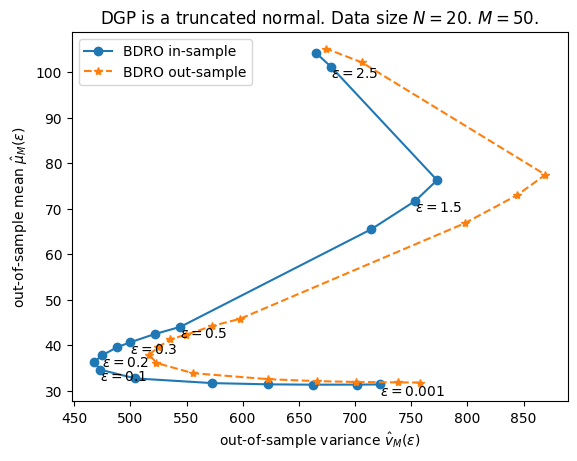

In [31]:
plt.plot(bdro_in_sample_var, bdro_in_sample_mean, marker='o', linestyle="-", label="BDRO in-sample")
# plt.plot(wass_in_sample_var, wass_in_sample_mean, marker='*', linestyle="--", label="Wasserstein DRO (p=2)")
plt.plot(bdro_out_sample_var, bdro_out_sample_mean, marker='*', linestyle="--", label="BDRO out-sample")

X_LABEL = "out-of-sample variance $\hat{v}_{M}(\epsilon)$"
Y_LABEL = "out-of-sample mean $\hat{\mu}_{M}(\epsilon)$"
plt.title(f"DGP is a truncated normal. Data size $N = 20$. $M = 50$.")
plt.legend()
plt.xlabel(X_LABEL)
plt.ylabel(Y_LABEL)

for i, epsilon in enumerate(bdro_in_sample_mean.index.values):
    if i % 2 == 0 and epsilon >= 0.1:
        plt.text(bdro_in_sample_var.iloc[i], bdro_in_sample_mean.iloc[i], f"$\epsilon={epsilon}$", ha='left', va='top')
    
    elif epsilon == 0.001:
        plt.text(bdro_in_sample_var.iloc[i], bdro_in_sample_mean.iloc[i], f"$\epsilon={epsilon}$", ha='left', va='top')

# for i, epsilon in enumerate(wass_in_sample_mean.index.values):
#     if i % 2 == 1 and epsilon >= 5:
#         plt.text(wass_in_sample_var.iloc[i], wass_in_sample_mean.iloc[i], f"$\hat{{\epsilon}}={epsilon}$", ha='left', va='top')
    